In [1]:
from typing import Callable
import re
import pandas as pd
import numpy as np
from dateutil.parser import parse
import matplotlib as mpl
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
mpl.style.use('dark_background')

In [2]:
def get_pattern(args: list[str]):
    pattern_builder = r"\[(?P<timestamp>.*?)\] "
    [*head, tail] = args
    for arg in head:
        pattern_builder += f"{arg}: (?P<{arg}>.*?), "
    pattern_builder += f"{tail}: (?P<{tail}>.*)"
    return re.compile(pattern_builder)

def create_df(results: list[dict], argdict: dict[str, Callable]) -> pd.DataFrame:
    if "timestamp" not in argdict:
        argdict["timestamp"] = lambda t: parse(t, fuzzy=True)
    df = pd.DataFrame(results)
    for key, mapfn in argdict.items():
        df[key] = df[key].map(mapfn)
    return df

def corr(df: pd.DataFrame, f1: str, f2: str) -> float:
    corr = df.corr().loc[f1, f2]
    if pd.isna(corr):
        return .0
    return corr

def autocorr(df: pd.DataFrame, f: str) -> float:
    return corr(df, "timestamp", f)

In [3]:
train_keys = {
    "kl": float,
    "lrMultiplier": float,
    "loss": float,
    "entropy": float,
    "explVarOld": float,
    "explVarNew": float,
}

eval_keys = {
    "numPlayouts": int,
    "win": int,
    "lose": int,
    "tie": int,
    "avgCurrStarted": float,
}

In [4]:
train_pattern = get_pattern(train_keys)
eval_pattern = get_pattern(eval_keys)

train_results, eval_results = [], []
with open("_zero/logs/losses.log", "r") as f:
    for line in f.readlines():
        assert line != "", "Empty line"
        train_match = train_pattern.search(line)
        if train_match is not None:
            train_results += [train_match.groupdict()]
        eval_match = eval_pattern.search(line)
        if eval_match is not None:
            eval_results += [eval_match.groupdict()]

train_df = create_df(train_results, train_keys)
eval_df = create_df(eval_results, eval_keys)

In [5]:
train_df.describe()

,timestamp,kl,lrMultiplier,loss,entropy,explVarOld,explVarNew
count,4979,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000,4979.000000
mean,2023-12-28 07:40:05.558046976,0.023931,0.097339,1.373734,0.779370,0.271460,0.296727
min,2023-12-26 21:06:27.423000,0.004770,0.088000,0.738510,0.380770,-0.216000,-0.041000
25%,2023-12-26 23:09:05.181000192,0.016310,0.088000,1.137240,0.580015,0.214000,0.236000
50%,2023-12-27 10:50:36.344000,0.021340,0.088000,1.239360,0.654120,0.287000,0.316000
75%,2023-12-29 21:13:22.092499968,0.028650,0.088000,1.511545,0.867565,0.337000,0.366000
max,2023-12-30 11:40:49.081000,0.158010,0.667000,4.453110,3.520380,0.637000,0.729000
std,NaN,0.011553,0.033105,0.391365,0.346933,0.095248,0.101381


In [6]:
train_df.corr().style.background_gradient("hot")

,timestamp,kl,lrMultiplier,loss,entropy,explVarOld,explVarNew
timestamp,1.000000,-0.155722,0.080771,-0.598159,-0.585683,0.549326,0.584502
kl,-0.155722,1.000000,0.045253,0.186042,0.186114,-0.177396,-0.168262
lrMultiplier,0.080771,0.045253,1.000000,0.331821,0.348424,-0.067356,-0.053695
loss,-0.598159,0.186042,0.331821,1.000000,0.970405,-0.731221,-0.753128
entropy,-0.585683,0.186114,0.348424,0.970405,1.000000,-0.665967,-0.691318
explVarOld,0.549326,-0.177396,-0.067356,-0.731221,-0.665967,1.000000,0.992355
explVarNew,0.584502,-0.168262,-0.053695,-0.753128,-0.691318,0.992355,1.000000


In [7]:
eval_df.describe()

,timestamp,numPlayouts,win,lose,tie,avgCurrStarted
count,100,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2023-12-28 07:45:54.249130240,2560.000000,6.890000,3.050000,0.060000,0.521000
min,2023-12-26 21:10:24.906000,1000.000000,0.000000,0.000000,0.000000,0.100000
25%,2023-12-26 23:13:04.659249920,1000.000000,6.000000,1.000000,0.000000,0.400000
50%,2023-12-27 10:54:51.796499968,3000.000000,8.000000,2.000000,0.000000,0.500000
75%,2023-12-29 21:16:46.788999936,4000.000000,9.000000,4.000000,0.000000,0.600000
max,2023-12-30 11:42:42.930000,5000.000000,10.000000,10.000000,2.000000,0.900000
std,NaN,1387.680282,2.494013,2.504037,0.277798,0.167751


In [8]:
eval_df.corr().style.background_gradient("hot")

,timestamp,numPlayouts,win,lose,tie,avgCurrStarted
timestamp,1.000000,0.882244,0.341737,-0.368237,0.251199,0.069251
numPlayouts,0.882244,1.000000,0.379887,-0.394761,0.147783,0.040094
win,0.341737,0.379887,1.000000,-0.993829,-0.019536,0.382216
lose,-0.368237,-0.394761,-0.993829,1.000000,-0.091482,-0.377656
tie,0.251199,0.147783,-0.019536,-0.091482,1.000000,-0.027311
avgCurrStarted,0.069251,0.040094,0.382216,-0.377656,-0.027311,1.000000


In [9]:
# Fairness of Evaluation

round_fairness_significance = .05
n_evaluation_games = 10

n_total_games = len(eval_df) * n_evaluation_games
mean_total_games = int(round(eval_df['avgCurrStarted'].mean() * n_total_games))
std_total_games = int(round(eval_df['avgCurrStarted'].std() * n_total_games))

round_fairness = eval_df["avgCurrStarted"].mean() - .5
round_fairness_autocorr = autocorr(eval_df, "avgCurrStarted")

round_fairness_doubt = False

print(f"[Info] The first player is said to have an unfair advantage in the game, so it should be checked that the number of plays were indeed balanced.")
print(f"[Info] {n_total_games} games played in total, distributed as: [{mean_total_games} - z * {std_total_games}, {mean_total_games} + z * {std_total_games}]")

if abs(round_fairness) > round_fairness_significance:
    round_fairness_doubt = True
    if round_fairness > .0:
        print(f"[Warn] The number of plays which the CURRENT player started is above the significance: {round_fairness:.4f} > {round_fairness_significance}")
    else:
        print(f"[Warn] The number of plays which the OPPONENT player started is above the significance: {-round_fairness:.4f} > {round_fairness_significance}")

if abs(round_fairness_autocorr) > round_fairness_significance:
    round_fairness_doubt = True
    if round_fairness_autocorr > .0:
        print(f"[Warn] The number of plays which the CURRENT player started tend to increase significantly: {round_fairness_autocorr:.4f} > {round_fairness_significance}")
    else:
        print(f"[Warn] The number of plays which the OPPONENT player started tend to increase significantly: {-round_fairness_autocorr:.4f} > {round_fairness_significance}")

if round_fairness_doubt:
    print(f"[Warn] If there is a doubt, you can relax the evaluation results in favour of the disadvantaged player.")

[Info] The first player is said to have an unfair advantage in the game, so it should be checked that the number of plays were indeed balanced.
[Info] 1000 games played in total, distributed as: [521 - z * 168, 521 + z * 168]
[Warn] The number of plays which the CURRENT player started tend to increase significantly: 0.0693 > 0.05
[Warn] If there is a doubt, you can relax the evaluation results in favour of the disadvantaged player.


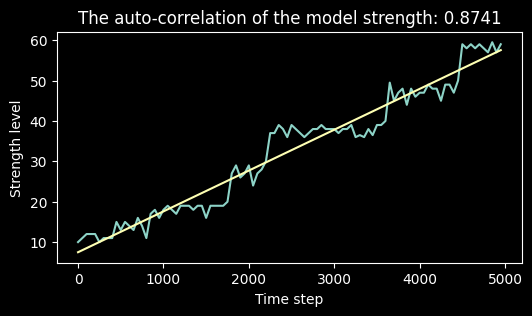

In [10]:
# Difficulty Estimation

eval_checkpoint = 50

eval_df["batch"] = eval_df.index * eval_checkpoint
eval_df.set_index("batch", inplace=True)

eval_df["strength"] = (eval_df["win"] + eval_df["tie"] / 2 + eval_df["numPlayouts"] / 100).round(2)

strength_significance = .7

strength_corr = autocorr(eval_df, "strength")
if strength_corr < strength_significance:
    print(f"[Warn] The current model tends not to improve over time, as indicated by the auto-correlation value: {strength_corr:.4f} < {strength_significance}")
    print(f"[Warn] Either the evaluation step is too harsh for the current model, or the model does not learn")

x_axis = eval_df.index.values.reshape(-1, 1)

strength_lr = LinearRegression()
strength_lr.fit(x_axis, eval_df["strength"].values)

strength_estimator = lambda x: strength_lr.coef_ * x + strength_lr.intercept_

fig, axes = plt.subplots(1, 1, figsize=(6, 3))

axes = eval_df["strength"].plot(ax=axes)
axes.set_title(f"The auto-correlation of the model strength: {strength_corr:.4f}")
axes.plot(x_axis, list(map(strength_estimator, x_axis)))
axes.set_xlabel('Time step')
axes.set_ylabel('Strength level')

plt.show()

[Info] Loss: Sum of policy loss and value loss, the main objective function to be minimized during training


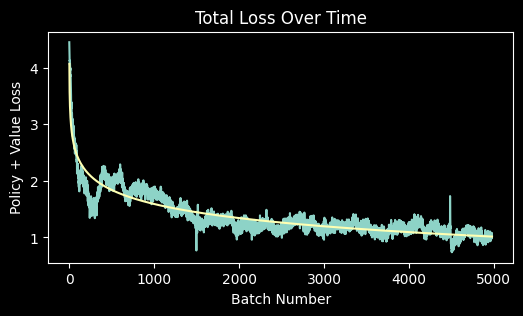

In [11]:
# Loss and Learning Rate

print(f"[Info] Loss: Sum of policy loss and value loss, the main objective function to be minimized during training")

loss_significance = -.5

loss_corr = autocorr(train_df, "loss")

if loss_corr > loss_significance:
    print(f"[Warn] The loss does not decrease significantly, which prevents the convergence of the model")
    print(f"[Warn] There might be a problem in loss function or hyperparameters")
    
x_axis = np.arange(len(train_df)).reshape(-1, 1) + 1
    
loss_lr = LinearRegression()
loss_lr.fit(np.log(x_axis), train_df["loss"])
loss_estimator = lambda x: loss_lr.coef_[0] * x + loss_lr.intercept_
    
fig, axes = plt.subplots(1, 1, figsize=(6, 3))
ax = train_df["loss"].plot(ax=axes)
ax.set_title("Total Loss Over Time")
ax.set_xlabel("Batch Number")
ax.set_ylabel("Policy + Value Loss")
ax.plot(x_axis, list(map(loss_estimator, np.log(x_axis))))

plt.show()

[Info] Entropy(probs): Measurement of how efficient the action prob. distribution is encoded
[Info] KL-Divergence(oldProbs, newProbs): Measurement of how much the new distribution differ from the old one


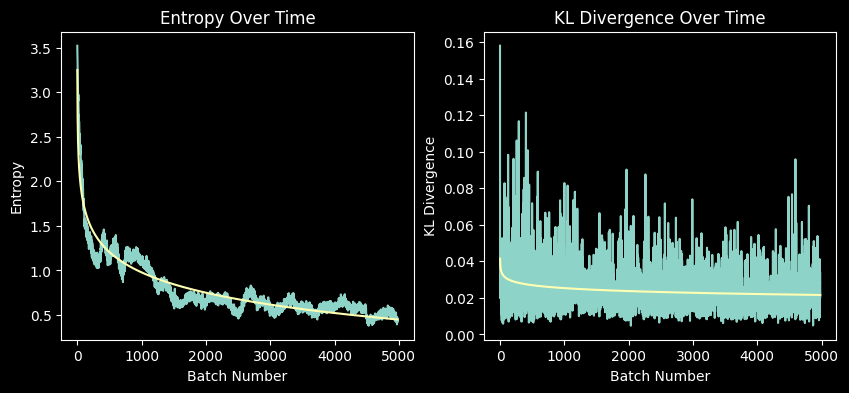

In [12]:
# Measuring Policy Estimation

print(f"[Info] Entropy(probs): Measurement of how efficient the action prob. distribution is encoded")
print(f"[Info] KL-Divergence(oldProbs, newProbs): Measurement of how much the new distribution differ from the old one")

entropy_significance = -.5
kl_significance = -0.01

entropy_corr = autocorr(train_df, "entropy")
kl_corr = autocorr(train_df, "kl")

if entropy_corr > entropy_significance:
    print(f"[Warn] Entropy seems to not decrease during training: {entropy_corr} > {entropy_significance}")
    print(f"[Warn] The learned action probabilities might be significantly imbalanced towards negative or positive")

if kl_corr > kl_significance:
    print(f"[Warn] KL Divergence does not decrease over time as much as expected: {kl_corr:.4f} > {kl_significance}")
    print(f"[Warn] The model might still need more training or there might be other destabilizing factors causing this issue")
    
x_axis = np.arange(len(train_df)).reshape(-1, 1) + 1

entropy_lr = LinearRegression()
entropy_lr.fit(np.log(x_axis), train_df["entropy"].values)
entropy_estimator = lambda x: entropy_lr.coef_[0] * x + entropy_lr.intercept_

kl_lr = LinearRegression()
kl_lr.fit(np.log(x_axis), train_df["kl"])
kl_estimator = lambda x: kl_lr.coef_[0] * x + kl_lr.intercept_

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax1 = train_df["entropy"].plot(ax=axes[0])
ax1.set_title("Entropy Over Time")
ax1.set_xlabel("Batch Number")
ax1.set_ylabel("Entropy")
ax1.plot(x_axis, list(map(entropy_estimator, np.log(x_axis))))

ax2 = train_df["kl"].plot(ax=axes[1])
ax2.set_title("KL Divergence Over Time")
ax2.set_xlabel("Batch Number")
ax2.set_ylabel("KL Divergence")
ax2.plot(x_axis, list(map(kl_estimator, np.log(x_axis))))

plt.show()

[Info] Explained-Variance(value): Measurement of how close the predicted value is to the actual reward


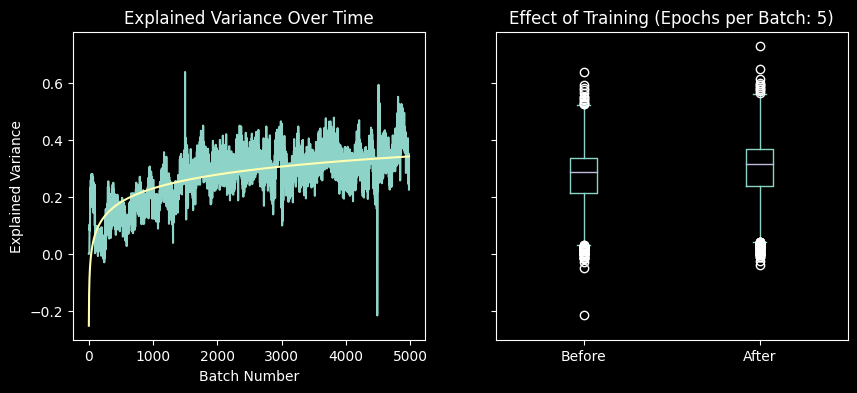

In [13]:
# Measuring Value Estimation

print(f"[Info] Explained-Variance(value): Measurement of how close the predicted value is to the actual reward")

expl_var_significance = .4
expl_var_difference_significance = .01

expl_var_corr = autocorr(train_df, "explVarOld")
if expl_var_corr < expl_var_significance:
    print(f"[Warn] The explained variance seems to not increase over time: {expl_var_corr} < {expl_var_significance}")
    print(f"[Warn] There might be an unknown learning issue which is probably caused by learning rate, loss function etc.")

expl_var_difference = (train_df["explVarNew"] - train_df["explVarOld"]).mean()
if expl_var_difference < expl_var_difference_significance:
    print(f"[Warn] The new explained variance tends not to differ significantly from the older one: {expl_var_difference:.4f} < {expl_var_difference_significance}")
    print(f"[Warn] Either the value loss is set correctly or the learning rate is too small")

n_epochs = 5

x_axis = np.arange(len(train_df)).reshape(-1, 1) + 1

expl_var_lr = LinearRegression()
expl_var_lr.fit(np.log(x_axis), train_df["explVarOld"].values)
expl_var_estimator = lambda x: expl_var_lr.coef_ * x + expl_var_lr.intercept_

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
ax1 = train_df["explVarOld"].plot(ax=axes[0])
ax1.set_title("Explained Variance Over Time")
ax1.set_xlabel("Batch Number")
ax1.set_ylabel("Explained Variance")
ax1.plot(x_axis, list(map(expl_var_estimator, np.log(x_axis))))

expl_var_difference_stats = train_df[["explVarOld", "explVarNew"]]
ax2 = expl_var_difference_stats.plot(kind="box", ax=axes[1])
ax2.set_title(f"Effect of Training (Epochs per Batch: {n_epochs})")
ax2.set_xticklabels(["Before", "After"])

plt.show()

/var/folders/gq/zf4jplr54kzc3vr7btq8ptc40000gp/T/ipykernel_7795/4207785269.py:32: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(x_axis, [0] * len(x_axis), 'k--', color="red")


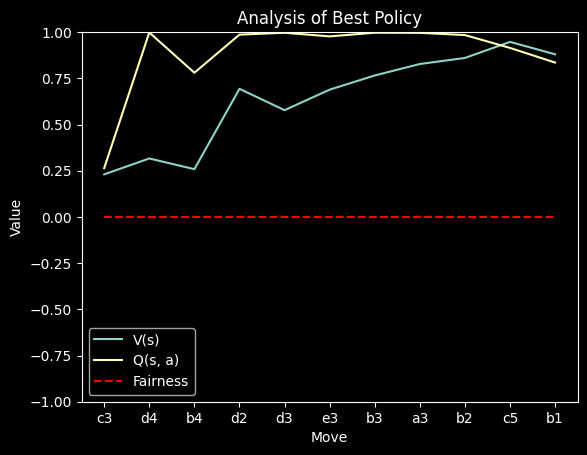

In [27]:
# Fairness of Game

from src import Gomoku, PolicyValueNet, UCT_Player, Pattern

Pi_s = "c3,d4,b4,d2,d3,e3,b3,a3,b2,c5,b1" # winning strategy for the first player

V_s = []
Q_sa = []

game_kwargs = {
    'M': 6,
    'N': 6,
    'K': 4,
}

game = Gomoku(**game_kwargs)
net = PolicyValueNet(game_kwargs=game_kwargs, model_file="_zero/models/curr_6_6_4.model")
net_player = UCT_Player(iterations=400, policy_value_fn=net.policy_value_fn_sorted, c_puct=5)

for move in Pattern.loc_to_move(Pi_s):
    probs, value = net.policy_value_fn_sorted(game)
    max_prob, max_action = max(probs)
    assert max_action == move, "The best policy is different from the given move"
    game.play(move)
    V_s += [value.detach().item()]
    Q_sa += [max_prob]
    
x_axis = Pi_s.split(",")
ax = plt.subplot(1, 1, 1)
ax.plot(x_axis, V_s)
ax.plot(x_axis, Q_sa)
ax.plot(x_axis, [0] * len(x_axis), 'k--', color="red")
ax.set_ylim(-1, 1)
ax.set_xlabel("Move")
ax.set_ylabel("Value")
ax.set_title("Analysis of Best Policy")
ax.legend(["V(s)", "Q(s, a)", "Fairness"])
plt.show()